<a href="https://colab.research.google.com/github/tiran543/Statistical-Learning-e23094/blob/main/Copy_of_fundamentals_of_probability_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


In [1]:
import numpy as np

# ---------------------------------------------
# Q1: Probability of landing within 1 unit of the boundary of a radius-10 disk
# ---------------------------------------------

R = 10  # disk radius
inner = 9  # inner radius of annulus

# ---------------------------------------------------------
# 1. Probability when the point is uniformly distributed over area
# ---------------------------------------------------------

# analytic probability
area_total = np.pi * R**2
area_annulus = np.pi * (R**2 - inner**2)
P_area = area_annulus / area_total

print("Model 1 (uniform area) analytic probability:", P_area)

# Monte-Carlo simulation
N = 2_000_000
# generate x,y uniformly inside square and reject outside disk
x = np.random.uniform(-R, R, N)
y = np.random.uniform(-R, R, N)
r_vals = np.sqrt(x*x + y*y)

inside_disk = r_vals <= R
annulus_points = (r_vals >= inner) & (r_vals <= R)

P_area_sim = annulus_points.sum() / inside_disk.sum()
print("Model 1 (uniform area) simulated probability:", P_area_sim)


# ---------------------------------------------------------
# 2. Probability when radius is uniform on [0,10] and angle uniform on [0,2pi]
# ---------------------------------------------------------

# analytic probability
P_radius = (R - inner) / R
print("Model 2 (uniform radius) analytic probability:", P_radius)

# Monte-Carlo simulation for model 2
R_samples = np.random.uniform(0, R, N)
theta_samples = np.random.uniform(0, 2*np.pi, N)

P_radius_sim = ((R_samples >= inner) & (R_samples <= R)).mean()
print("Model 2 (uniform radius) simulated probability:", P_radius_sim)

Model 1 (uniform area) analytic probability: 0.18999999999999997
Model 1 (uniform area) simulated probability: 0.18966985172142606
Model 2 (uniform radius) analytic probability: 0.1
Model 2 (uniform radius) simulated probability: 0.0999395


Model 1: Random point means uniform over the area

If the point is equally likely to be anywhere inside the disk, then the sample space is all points whose distance from the center is at most 10. The event A consists of all points whose distance from the center is between 9 and 10. This is the outer ring of the disk.

The total area of the disk is pi * 10^2 = 100pi.
The area of the ring (annulus) is pi * (10^2 – 9^2) = pi * (100 – 81) = 19pi.

Therefore the probability is:

P(A) = (area of annulus) / (area of disk) = 19pi / (100pi) = 0.19.

Model 2: Radius and direction chosen independently

Now assume the distance from the center (call it R) is uniform between 0 and 10, and the angle is uniform between 0 and 2*pi. In this setup, the event A is the set of radii between 9 and 10.

Since R is uniform on a length of 10, the probability that R falls between 9 and 10 is:

P(A) = (10 – 9) / 10 = 0.1.

Why the answers are different

The two models interpret “chosen at random” in different ways.

In the first interpretation, every part of the disk’s area is equally likely. Since outer circles have much more area than inner circles, a point is more likely to land near the boundary.

In the second interpretation, all radii from 0 to 10 are given the same chance, even though larger radii correspond to much bigger circles. This makes the outer region appear less likely than it actually is under equal-area selection.

Because uniform-area and uniform-radius are not the same, the two probabilities (0.19 and 0.10) differ.

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

In [2]:
import numpy as np

def simulate_q2_bertrand(n_simulations=100000):
    """
    Simulates Bertrand's Paradox to show how 'random' selection
    leads to different probabilities.
    """
    print("--- Q2: Bertrand's Paradox Simulation ---")

    # Method 1: Random Endpoints
    # Choose two random angles on the circumference and connect them.
    theta1 = np.random.uniform(0, 2*np.pi, n_simulations)
    theta2 = np.random.uniform(0, 2*np.pi, n_simulations)
    # Length of chord between two points on unit circle: sqrt(2 - 2*cos(delta_theta))
    chord_lengths = np.sqrt(2 - 2*np.cos(theta1 - theta2))
    p1 = np.mean(chord_lengths > np.sqrt(3))

    # Method 2: Random Radius (Radial Distance)
    # Choose a random radius and a random point along it to be the midpoint.
    r = np.random.uniform(0, 1, n_simulations)
    # Chord is longer than sqrt(3) if midpoint is less than 0.5 from center
    p2 = np.mean(r < 0.5)

    # Method 3: Random Midpoint (Uniformly over the Area)
    # Choose a random point anywhere inside the circle to be the midpoint.
    # To get uniform area distribution, we use sqrt of a uniform variable for radius.
    rho = np.sqrt(np.random.uniform(0, 1, n_simulations))
    # Chord is longer than sqrt(3) if midpoint falls in the inner circle (r < 0.5)
    p3 = np.mean(rho < 0.5)

    print(f"Model 1 (Random Endpoints): Empirical = {p1:.4f} (Theoretical 1/3 ≈ 0.3333)")
    print(f"Model 2 (Random Radius):    Empirical = {p2:.4f} (Theoretical 1/2 = 0.5000)")
    print(f"Model 3 (Random Midpoint):  Empirical = {p3:.4f} (Theoretical 1/4 = 0.2500)")

# Run the simulation
simulate_q2_bertrand()

--- Q2: Bertrand's Paradox Simulation ---
Model 1 (Random Endpoints): Empirical = 0.3372 (Theoretical 1/3 ≈ 0.3333)
Model 2 (Random Radius):    Empirical = 0.4997 (Theoretical 1/2 = 0.5000)
Model 3 (Random Midpoint):  Empirical = 0.2506 (Theoretical 1/4 = 0.2500)


#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

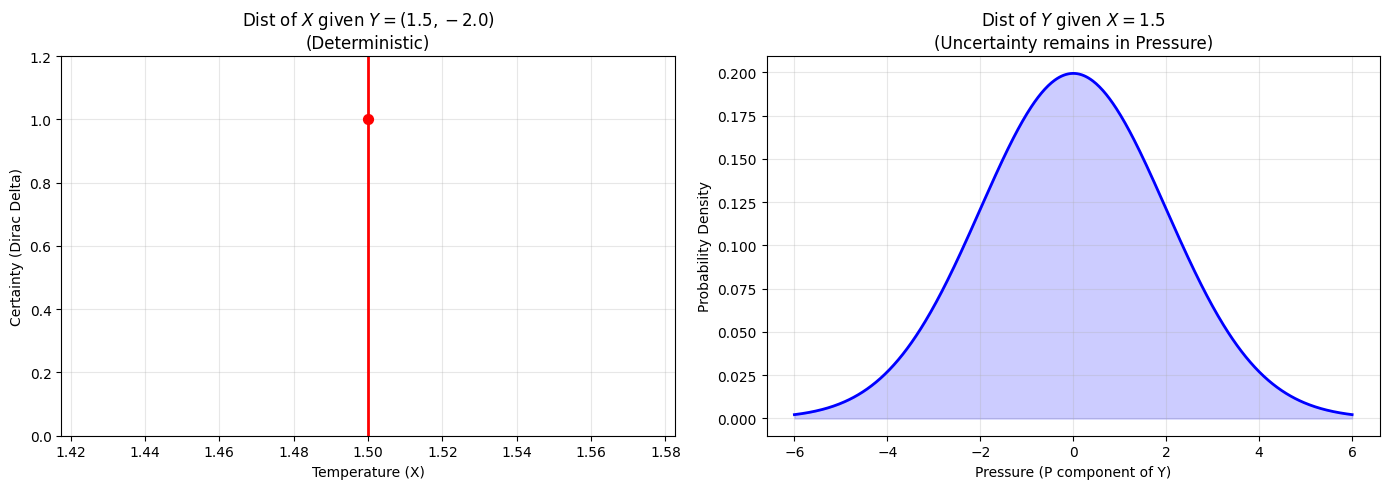

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Parameters ---
# X (Temperature) ~ N(0, 1)
# P (Pressure) ~ N(0, 4) -> Standard Deviation = 2
# Y = (X, P) is the joint state

# 1. Conditioning on Y: Suppose we observe Y = (1.5, -2.0)
t_obs, p_obs = 1.5, -2.0

# 2. Conditioning on X: Suppose we only observe X = 1.5
x_fixed = 1.5

# Setup for plotting
x_axis = np.linspace(0.5, 2.5, 500)
p_axis = np.linspace(-6, 6, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Conditional Distribution of X given Y ---
# Since Y contains X, knowing Y means X is known with 100% certainty.
# This results in a Dirac Delta function (a spike).
ax1.axvline(x=t_obs, color='red', linestyle='-', linewidth=2, label='Fixed Value')
ax1.scatter([t_obs], [1], color='red', s=50, zorder=3)
ax1.set_title(f"Dist of $X$ given $Y=({t_obs}, {p_obs})$\n(Deterministic)")
ax1.set_xlabel("Temperature (X)")
ax1.set_ylabel("Certainty (Dirac Delta)")
ax1.set_ylim(0, 1.2)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Conditional Distribution of Y given X ---
# Since P is independent of X, knowing X doesn't change the distribution of P.
# Y given X is effectively the distribution of P.
pdf_p = norm.pdf(p_axis, loc=0, scale=2)
ax2.plot(p_axis, pdf_p, color='blue', lw=2, label='Pressure Dist')
ax2.fill_between(p_axis, pdf_p, color='blue', alpha=0.2)
ax2.set_title(f"Dist of $Y$ given $X={x_fixed}$\n(Uncertainty remains in Pressure)")
ax2.set_xlabel("Pressure (P component of Y)")
ax2.set_ylabel("Probability Density")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

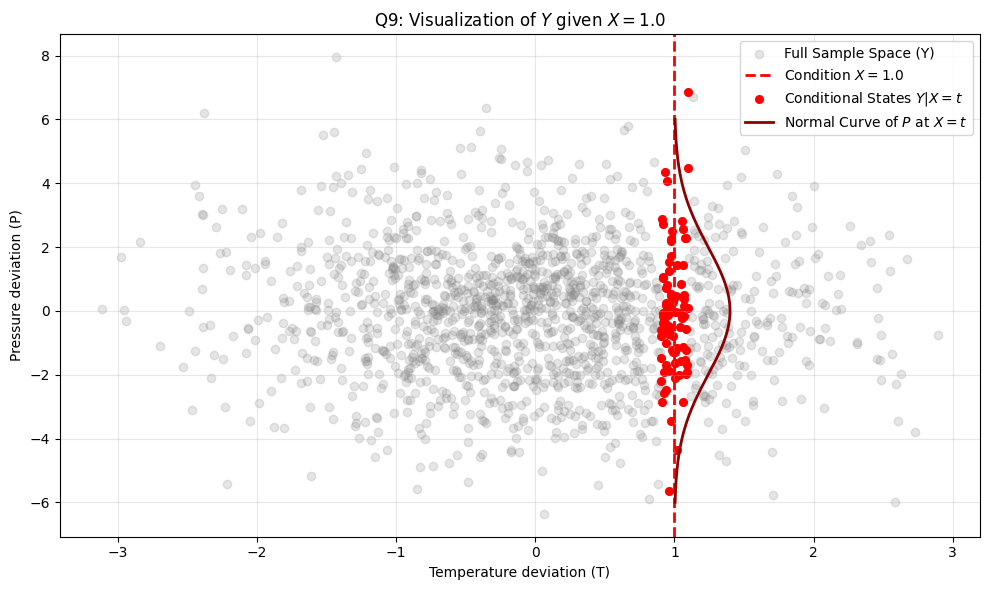

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define the parameters for the joint state Y = (T, P)
# Temperature T follows N(0, 1)
# Pressure P follows N(0, 4) -> Standard deviation is 2
n_samples = 1500
t_samples = np.random.normal(0, 1, n_samples)
p_samples = np.random.normal(0, 2, n_samples)

# 2. Set the condition: we observe X (temperature) is exactly 1.0
t_fixed = 1.0

# 3. Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the total cloud of possible states (Unconditional Y)
ax.scatter(t_samples, p_samples, alpha=0.2, color='gray', label='Full Sample Space (Y)')

# Draw the line representing the condition X = t
ax.axvline(x=t_fixed, color='red', linestyle='--', linewidth=2, label=f'Condition $X = {t_fixed}$')

# Filter samples roughly satisfying the condition for visualization
epsilon = 0.1
mask = np.abs(t_samples - t_fixed) < epsilon
ax.scatter(t_samples[mask], p_samples[mask], color='red', s=30, label='Conditional States $Y|X=t$')

# Overlap the PDF curve of Pressure to show the resulting 1D distribution
p_axis = np.linspace(-6, 6, 500)
p_pdf = norm.pdf(p_axis, 0, 2) * 2  # Scaled for visual clarity on the plot
ax.plot(t_fixed + p_pdf, p_axis, color='darkred', lw=2, label='Normal Curve of $P$ at $X=t$')

ax.set_title(f"Q9: Visualization of $Y$ given $X = {t_fixed}$")
ax.set_xlabel("Temperature deviation (T)")
ax.set_ylabel("Pressure deviation (P)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


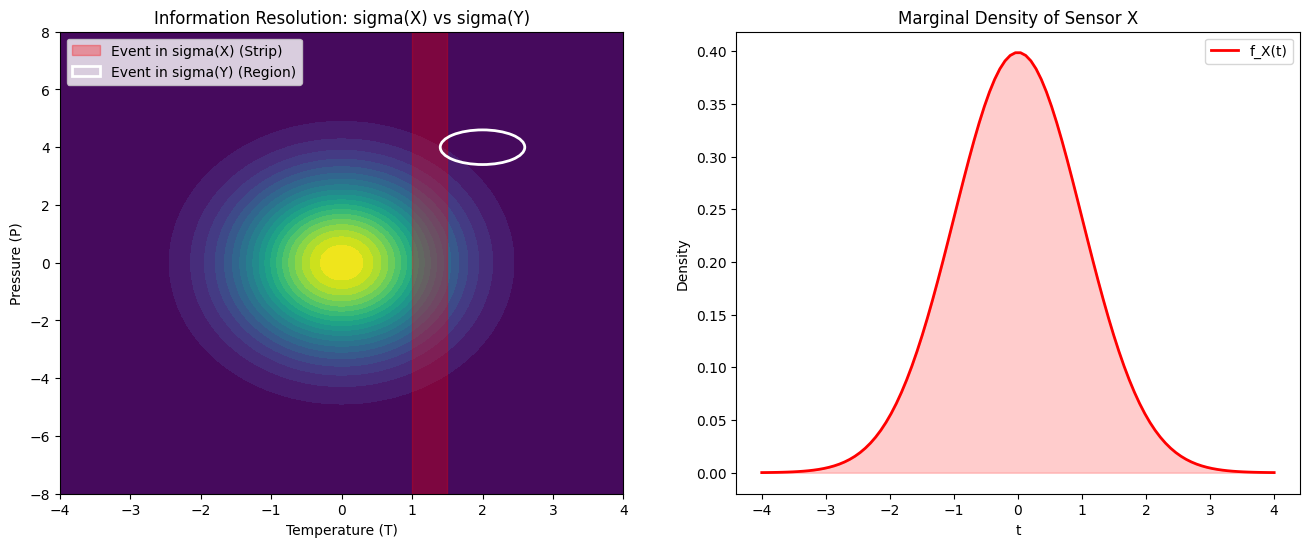

h(X): 1.4189 nats
h(Y): 3.5310 nats
h(Y|X): 2.1121 nats
h(X|Y): -inf (since X is completely determined by Y)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# 1. Define Model Parameters
# Temperature (T) ~ N(0, 1), Pressure (P) ~ N(0, 4)
# Y = (T, P) represents the full state; X = T is the sensor reading.
mean = [0, 0]
cov = [[1, 0], [0, 4]]
rv = multivariate_normal(mean, cov)

# 2. Visualization of Information Resolution (sigma-algebras)
x = np.linspace(-4, 4, 100)
p = np.linspace(-8, 8, 100)
X_grid, P_grid = np.meshgrid(x, p)
pos = np.dstack((X_grid, P_grid))
Z = rv.pdf(pos)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Joint Density f_Y and sigma-algebra comparison
contour = ax[0].contourf(X_grid, P_grid, Z, levels=20, cmap='viridis')
ax[0].set_title("Information Resolution: sigma(X) vs sigma(Y)")
ax[0].set_xlabel("Temperature (T)")
ax[0].set_ylabel("Pressure (P)")

# sigma(X) only sees temperature; it resolves events as vertical strips.
ax[0].axvspan(1.0, 1.5, color='red', alpha=0.3, label='Event in sigma(X) (Strip)')
# sigma(Y) resolves both; it can see specific regions or points.
circle = plt.Circle((2, 4), 0.6, color='white', fill=False, linewidth=2, label='Event in sigma(Y) (Region)')
ax[0].add_patch(circle)
ax[0].legend()

# Plot 2: Marginal Density f_X(t)
x_pdf = norm.pdf(x, 0, 1)
ax[1].plot(x, x_pdf, 'r-', lw=2, label='f_X(t)')
ax[1].fill_between(x, x_pdf, color='red', alpha=0.2)
ax[1].set_title("Marginal Density of Sensor X")
ax[1].set_xlabel("t")
ax[1].set_ylabel("Density")
ax[1].legend()

plt.show()

# 3. Differential Entropy Calculations (nats)
# h(X) = 0.5 * ln(2 * pi * e * sigma^2)
h_X = 0.5 * np.log(2 * np.pi * np.e * 1)
h_P = 0.5 * np.log(2 * np.pi * np.e * 4)
h_Y = h_X + h_P

print(f"h(X): {h_X:.4f} nats")
print(f"h(Y): {h_Y:.4f} nats")
print(f"h(Y|X): {h_P:.4f} nats")
print("h(X|Y): -inf (since X is completely determined by Y)")

Q10: Comprehensive Analysis of the Continuous ModelIn this chemical reactor model, the system's full state is represented by a random vector $Y = (T, P)$, where $T$ is the temperature deviation and $P$ is the pressure deviation. We also consider a single temperature sensor $X$, defined as $X = T$.  1. Information Resolution and $\sigma$-algebras$\sigma(X)$: This $\sigma$-algebra represents the information available from the temperature sensor alone. In the $T-P$ coordinate plane, an "event" in $\sigma(X)$ takes the form of a vertical strip. This is because the sensor can distinguish between different temperatures but is "blind" to changes in pressure.  $\sigma(Y)$: This is the full Borel $\sigma$-algebra $\mathfrak{B}(\mathbb{R}^2)$. It represents complete knowledge of the system and can resolve any specific point or region $(t, p)$ within the reactor's state space.  Mathematical Inclusion: Since $X$ is a direct component of $Y$, it follows that $\sigma(X) \subset \sigma(Y)$. This confirms that the full state $Y$ provides a strictly higher resolution of information than the single sensor $X$.  2. Probabilities and DensitiesJoint Density ($f_Y$): The state $Y$ follows a bivariate normal distribution. Because temperature and pressure are independent, the joint density is the product of their marginals: $f_Y(t, p) = f_T(t) \cdot f_P(p)$.  Marginal Density ($f_X$): The temperature sensor $X$ follows a standard normal distribution $N(0, 1)$.  Calculation: The probability $P(X \le 0) = 0.5$, which follows from the symmetry of the normal distribution centered at the origin.  3. Information Theory and Differential EntropyDifferential entropy (measured in nats) quantifies the uncertainty in these continuous variables:  Unconditional Entropy ($h(X)$): The uncertainty of the temperature sensor is approximately 1.4189 nats.  Joint Entropy ($h(Y)$): The total uncertainty of the system (combining $T$ and $P$) is approximately 3.5310 nats.  Conditional Entropy ($h(Y|X)$): This represents the uncertainty remaining in the system once the temperature is known. Because $T$ and $P$ are independent, $h(Y|X) = h(P)$, which is approximately 2.1121 nats.  Deterministic Limit ($h(X|Y)$): Because $X$ is completely determined by $Y$, there is no uncertainty left regarding $X$ once $Y$ is observed. In this continuous model, the entropy approaches $-\infty$, illustrating a key difference from discrete models where the limit is 0.  4. Functional Relationship and Measurability  Measurability: $X$ is a measurable function of $Y$.  Projection: Mathematically, $X$ is the result of the projection mapping $\pi_1: \mathbb{R}^2 \to \mathbb{R}$. This mapping "strips away" the pressure data, leaving only the temperature $t$, proving that all information in $X$ is natively contained within $Y$

In the continuous probability model for the chemical reactor, conditioning the joint state $Y = (T, P)$ on a specific temperature $X = t$ changes our perspective from the entire 2D plane to a specific subset of the probability space.  Dimensionality and Support: While the unconditional joint state $Y$ spans the entire 2D plane $\mathbb{R}^2$, the conditional distribution $Y|X=t$ is supported only on a 1D vertical line where the temperature is fixed at $t$.  Role of Independence: Because temperature ($T$) and pressure ($P$) are independent random variables, knowing the value of $T$ does not update our knowledge regarding $P$.  The Resulting Distribution: Given $X=t$, the joint state $Y$ is no longer a bivariate distribution in the traditional sense. Instead, it behaves as a univariate normal distribution $N(0, 4)$ along the axis of pressure, positioned at the constant temperature $t$.  Information Interpretation: Conditioning on $X$ represents a scenario where the temperature sensor provides a perfect reading, thereby eliminating all uncertainty in the $T$ dimension. However, because the sensors are independent, all original uncertainty regarding the pressure remains.  

In our chemical reactor model, X represents the temperature deviation and Y=(T,P) represents the full state of the system (both temperature and pressure). Conditioning allows us to see how observing one variable reduces the uncertainty of the other.  

1. Conditional Distribution of X given Y=(t,p)
Definition: This is the probability distribution of the temperature X, given that we know the exact joint state Y (both temperature t and pressure p).

Result: Since Y explicitly includes X, there is no remaining uncertainty.

Form: The distribution is a Dirac Delta function δ(x−t).

Interpretation: If you know the full state of the reactor, you know the temperature with 100% certainty.

2. Conditional Distribution of Y given X=t
Definition: This is the probability distribution of the full state Y, given that we only know the temperature X is equal to t.

Result: Because temperature (T) and pressure (P) are independent in this model, knowing T tells us nothing about P.

Form: The distribution is a 1D Normal Distribution N(0,4) shifted to the vertical line where T=t in the T−P plane.

Interpretation: Even if you know the temperature deviation exactly, the pressure remains an uncertain random variable following its original marginal distribution.

3. Physical Interpretation of Conditioning
Conditioning on X: This represents a "partial observation". It narrows the possibilities of the system's state to a single vertical line in the probability space, but leaves the vertical position (pressure) unknown.

Conditioning on Y: This represents a "complete observation". It collapses all uncertainty, pinpointing the system to a single coordinate (t,p) in the probability space.

Bertrand's Paradox demonstrates that "random" is not well-defined for continuous variables unless the mechanism for selection is specified. The problem asks: What is the probability that a random chord of a circle is longer than the side of an inscribed equilateral triangle?The length of the side of an equilateral triangle inscribed in a unit circle is $\sqrt{3}$. There are three common "solutions" based on how you define a "random chord."1. The Random Endpoints MethodMechanism: Choose two points independently and uniformly on the circumference of the circle and connect them.Logic: Without loss of generality, fix the first point as a vertex of the inscribed triangle. The chord is longer than $\sqrt{3}$ only if the second point falls on the arc between the other two vertices of the triangle.Calculation: This arc represents $1/3$ of the total circumference.Result: $P = 1/3 \approx 0.333$2. The Random Radius MethodMechanism: Choose a radius of the circle and then choose a point at random along that radius to be the midpoint of the chord.Logic: A chord is longer than the side of the inscribed triangle ($\sqrt{3}$) if its midpoint is closer to the center of the circle than to the circumference.Calculation: The side of the inscribed triangle is exactly $1/2$ the distance from the center to the circumference along the radius. Therefore, the midpoint must fall within the first half of the radius.Result: $P = 1/2 = 0.500$3. The Random Midpoint MethodMechanism: Choose a point anywhere within the circle and let that point be the midpoint of the chord.Logic: A chord is longer than the side of the inscribed triangle if its midpoint falls within a smaller concentric circle that is tangent to the sides of the triangle.Calculation: The radius of this smaller "inner" circle is $1/2$. The area of the inner circle is $\pi(1/2)^2 = \pi/4$, while the area of the large circle is $\pi(1)^2 = \pi$.Ratio: $(\pi/4) / \pi = 1/4$.Result: $P = 1/4 = 0.250$